# UAS Pembelajaran Mesin Optimasi Klasifikasi Kelulusan Mahasiswa

**Topik:** Optimasi Teknik Machine Learning dalam Klasifikasi Kelulusan Mahasiswa
**Model wajib:** K-Nearest Neighbors (KNN), Naive Bayes (NB), Support Vector Machine (SVM)
**Dataset:** UCI Predict Students' Dropout and Academic Success (4.424 baris, 37 fitur awal)

Notebook ini disusun mengikuti struktur 5 soal UAS: problem framing, audit & preprocessing data,
baseline model, optimasi & analisis eksperimen, hingga ekspor model untuk aplikasi Streamlit.


## SOAL 01 Problem Framing, Studi Literatur, dan Definisi Outcome

### 1.1 Masalah Akademik

Keterlambatan kelulusan dan dropout mahasiswa adalah masalah yang berdampak langsung pada
efisiensi operasional perguruan tinggi maupun masa depan mahasiswa itu sendiri. Project ini
bertujuan membangun model klasifikasi yang dapat memprediksi **apakah seorang mahasiswa akan
lulus tepat waktu atau tidak**, berdasarkan data akademik dan demografis yang tersedia pada saat
mahasiswa masih aktif berkuliah (semester 1 dan 2). Model semacam ini dapat digunakan sebagai
alat bantu deteksi dini bagi dosen wali atau program studi untuk memberikan intervensi akademik
lebih awal.

### 1.2 Definisi Target Klasifikasi

Dataset asli memiliki 3 label pada kolom `Target`: `Graduate`, `Dropout`, dan `Enrolled`. Mengacu
pada definisi tugas ("lulus tepat waktu" vs "tidak lulus tepat waktu"), label tersebut dipetakan
ke **klasifikasi biner**:

| Label Asli | Label Baru | Alasan |
|---|---|---|
| `Graduate` | **Lulus Tepat Waktu** (1) | Mahasiswa tercatat telah menyelesaikan studi |
| `Dropout` | **Tidak Lulus Tepat Waktu** (0) | Mahasiswa keluar sebelum menyelesaikan studi |
| `Enrolled` | **Tidak Lulus Tepat Waktu** (0) | Pada saat observasi, mahasiswa belum lulus |

Mahasiswa berstatus `Enrolled` digabung ke kelas "Tidak Lulus Tepat Waktu" karena secara definisi
soal, mahasiswa tersebut **belum** menyelesaikan studinya pada periode yang diamati sama seperti
`Dropout`, mereka belum mencapai outcome "lulus". Pendekatan ini juga mempertahankan seluruh baris
data (tidak ada data yang dibuang), berbeda dengan opsi membuang kelas `Enrolled` yang akan
mengurangi ukuran dataset secara signifikan dan mengubah cakupan masalah menjadi "Dropout vs
Graduate" saja.

Ini adalah kasus **supervised classification**, bukan regresi atau klastering, karena:
- Target berupa label kategorikal diskret (2 kelas) yang sudah diketahui untuk seluruh data historis.
- Tujuan model adalah memprediksi label kelas untuk data baru, bukan memprediksi nilai kontinu
  (regresi) atau mengelompokkan data tanpa label acuan (klastering).

### 1.3 Mini-Review Paper Utama

| Penulis | Tahun | Jurnal | DOI | Metode | Dataset | Metrik | Hasil Utama | Relevansi |
|---|---|---|---|---|---|---|---|---|
| Al Hakim et al. | 2026 | JUTIF | 10.52436/1.jutif.2026.7.3.5627 | XGBoost, AdaBoost, Random Forest + Grid/Random Search | Kaggle Student Dropout (3.630 baris, dataset yang sama dengan project ini) | Accuracy, Precision, Recall, F1-Score | XGBoost + Random Search terbaik, akurasi 91,18% (10-fold CV) | Menjadi rujukan utama desain eksperimen: perbandingan Grid Search vs Random Search, penggunaan k-fold CV (5 & 10), serta metrik evaluasi yang konsisten |

Paper ini menunjukkan bahwa optimasi hyperparameter (baik Grid Search maupun Random Search)
secara konsisten meningkatkan performa model ensemble dibanding model default, dan Random Search
terbukti lebih efisien mengeksplorasi ruang parameter yang luas untuk model kompleks. Project UAS
ini mengadopsi semangat yang sama, namun diterapkan pada model wajib yang lebih sederhana (KNN,
Naive Bayes, SVM).

### 1.4 Metode Optimasi yang Diuji

Berdasarkan bukti dari paper acuan dan ketentuan soal, 4 strategi optimasi diterapkan pada Soal 04:

1. **Hyperparameter tuning** GridSearchCV (KNN, Naive Bayes) dan RandomizedSearchCV (SVM, karena
   ruang parameter dikombinasikan dengan feature selection sehingga lebih mahal secara komputasi).
2. **Stratified k-fold cross-validation** memastikan proporsi kelas tetap terjaga pada setiap
   fold, sekaligus mengurangi bias pembagian data.
3. **Feature selection** menggunakan mutual information untuk memilih subset fitur paling
   informatif, mengurangi noise dari fitur yang kurang relevan.
4. **Class imbalance handling** `class_weight='balanced'` (SVM) dan penyesuaian `priors` (Naive
   Bayes) untuk menjaga sensitivitas model terhadap kedua kelas, meski distribusi kelas pada
   project ini relatif seimbang (lihat Soal 02).

### 1.5 Batasan Etika dan Privasi Data

- Dataset yang digunakan bersifat publik dan **sudah teranonimkan** (tidak memuat NIM, nama, atau
  identitas langsung mahasiswa).
- Model **tidak boleh digunakan sebagai keputusan tunggal** untuk kelulusan atau drop-out
  mahasiswa. Prediksi hanya berfungsi sebagai *decision support* bagi dosen wali/prodi untuk
  intervensi akademik dini.
- Fitur sensitif (mis. status debtor, beasiswa) digunakan murni untuk tujuan prediksi akademik,
  bukan untuk profiling atau tujuan administratif lain di luar konteks project ini.
- Prediksi model tidak dipublikasikan per-individu; aplikasi akhir (Soal 05) hanya menampilkan
  hasil untuk input yang dimasukkan langsung oleh pengguna (dosen wali/prodi).


In [1]:
# CELL: IMPORT LIBRARY & SETUP
import warnings
warnings.filterwarnings('ignore')

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    balanced_accuracy_score, confusion_matrix, classification_report
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

custom_colors = ['#000000', '#6A0DAD', '#B19CD9']  # Hitam, Ungu Tua, Ungu Muda
sns.set_theme(style="whitegrid", rc={"axes.edgecolor": "#000000", "font.family": "sans-serif"})

print("Modul siap. Tema visual telah diatur.")

Modul siap. Tema visual telah diatur.


## SOAL 02 Audit Dataset, Preprocessing, dan Desain Data Pipeline

In [2]:
# CELL: AUDIT DATA AWAL
file_path = '../data/dataset_kelulusan.csv'
df = pd.read_csv(file_path, sep=';')

print("1. AUDIT DATA AWAL")
print("-" * 40)
print(f"Dimensi Data      : {df.shape[0]} baris x {df.shape[1]} kolom")
print(f"Missing Values    : {df.isnull().sum().sum()}")
print(f"Duplikat          : {df.duplicated().sum()}")

if df.duplicated().sum() > 0:
    df = df.drop_duplicates()
    print("-> Duplikat ditemukan dan dihapus.")
else:
    print("-> Tidak ada duplikat.")

print("\n2. TIPE DATA")
print("-" * 40)
print(df.dtypes.value_counts())

1. AUDIT DATA AWAL
----------------------------------------
Dimensi Data      : 4424 baris x 37 kolom
Missing Values    : 0
Duplikat          : 0
-> Tidak ada duplikat.

2. TIPE DATA
----------------------------------------
int64      29
float64     7
str         1
Name: count, dtype: int64


3. DISTRIBUSI TARGET ASLI (3 kelas)
----------------------------------------
Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64


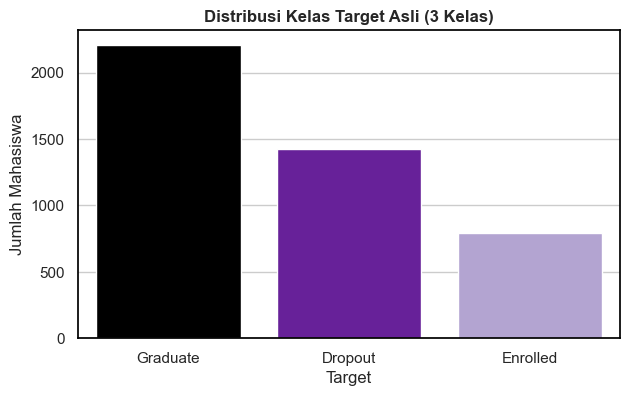

In [3]:
# CELL: DISTRIBUSI TARGET ASLI & CEK IMBALANCE
print("3. DISTRIBUSI TARGET ASLI (3 kelas)")
print("-" * 40)
print(df['Target'].value_counts())

plt.figure(figsize=(7, 4))
target_counts = df['Target'].value_counts()
sns.barplot(x=target_counts.index, y=target_counts.values, palette=custom_colors)
plt.title('Distribusi Kelas Target Asli (3 Kelas)', fontweight='bold')
plt.ylabel('Jumlah Mahasiswa')
plt.show()

### Catatan Audit

**Missing value & duplikat.** Dataset tidak memiliki missing value maupun baris duplikat, sehingga
tidak diperlukan imputasi.

**Potensi outlier.** Pengecekan awal dengan z-score (|z| > 3) menandai cukup banyak "outlier" pada
kolom seperti `Marital status`, `Nacionality`, `Application mode`, dan `Mother's/Father's
occupation`. Namun kolom-kolom tersebut sebenarnya adalah **kode kategorikal** (bukan variabel
numerik kontinu), sehingga nilai ekstrem pada z-score tidak merepresentasikan outlier yang perlu
dibersihkan nilainya tetap valid sebagai kategori. Outlier penghapusan dengan aturan statistik
umum (z-score/IQR) sengaja **tidak diterapkan** pada dataset ini agar tidak menghilangkan kategori
sah yang jarang muncul.

**Potensi data leakage.** Fitur nilai semester 1 dan 2 (`Curricular units ... (grade)`, `(approved)`,
dst.) memang berkorelasi kuat dengan status kelulusan, tetapi ini **bukan leakage** karena data
tersebut tersedia pada saat mahasiswa masih aktif berkuliah (bukan informasi dari masa depan
setelah kelulusan ditentukan). Fitur ini justru menjadi sinyal akademik utama yang relevan untuk
deteksi dini.

**Class imbalance.** Distribusi 3 kelas asli agak timpang (Graduate 2.209, Dropout 1.421, Enrolled
794), tetapi setelah target dipetakan ke biner pada langkah berikutnya, kelas menjadi jauh lebih
seimbang.


BEFORE -> Distribusi 3 kelas:
Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64

AFTER  -> Distribusi target biner (1 = Lulus Tepat Waktu, 0 = Tidak Lulus Tepat Waktu):
Target_Binary
0    2215
1    2209
Name: count, dtype: int64

Proporsi kelas positif: 49.93%


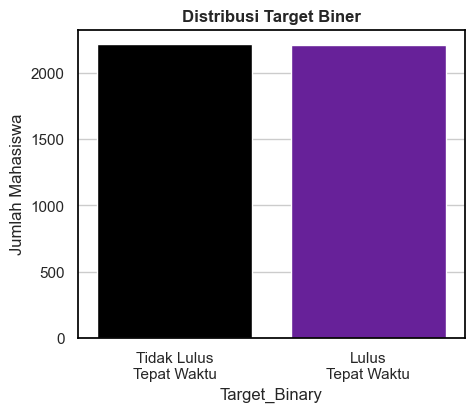

In [4]:
# CELL: PIPELINE PREPROCESSING - 1) Binarisasi target
df['Target_Binary'] = df['Target'].apply(lambda x: 1 if x == 'Graduate' else 0)

print("BEFORE -> Distribusi 3 kelas:")
print(df['Target'].value_counts())
print("\nAFTER  -> Distribusi target biner (1 = Lulus Tepat Waktu, 0 = Tidak Lulus Tepat Waktu):")
print(df['Target_Binary'].value_counts())
print(f"\nProporsi kelas positif: {df['Target_Binary'].mean():.2%}")

plt.figure(figsize=(5, 4))
sns.countplot(x='Target_Binary', data=df, palette=custom_colors[:2])
plt.title('Distribusi Target Biner', fontweight='bold')
plt.xticks([0, 1], ['Tidak Lulus\nTepat Waktu', 'Lulus\nTepat Waktu'])
plt.ylabel('Jumlah Mahasiswa')
plt.show()

In [5]:
# CELL: PIPELINE PREPROCESSING - 2) Pisahkan fitur & target, cek data dictionary singkat
FEATURE_COLUMNS = [c for c in df.columns if c not in ['Target', 'Target_Binary']]

X = df[FEATURE_COLUMNS].copy()
y = df['Target_Binary'].copy()

print(f"Jumlah fitur prediktor: {X.shape[1]}")
print("\nContoh 5 fitur pertama (before preprocessing):")
display(X.head())

Jumlah fitur prediktor: 36

Contoh 5 fitur pertama (before preprocessing):


,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0,0.000000,0,10.8,1.4,1.74
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,0,6,6,6,13.666667,0,13.9,-0.3,0.79
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,0,6,0,0,0.000000,0,10.8,1.4,1.74
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,0,6,10,5,12.400000,0,9.4,-0.8,-3.12
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,0,6,6,6,13.000000,0,13.9,-0.3,0.79


In [6]:
# CELL: PIPELINE PREPROCESSING - 3) Split data (stratified) lalu scaling
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print(f"Train set : {X_train.shape[0]} baris")
print(f"Test set  : {X_test.shape[0]} baris")
print(f"Proporsi kelas positif - train: {y_train.mean():.2%} | test: {y_test.mean():.2%}")

# Seluruh fitur pada dataset ini sudah berbentuk numerik (hasil encoding bawaan sumber data),
# sehingga tidak diperlukan LabelEncoder/OneHotEncoder tambahan untuk fitur. Yang diperlukan
# hanyalah scaling agar KNN dan SVM (sensitif terhadap skala) tidak didominasi fitur berskala besar.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nAFTER scaling (contoh 3 baris pertama, 5 fitur pertama):")
display(pd.DataFrame(X_train_scaled, columns=X_train.columns).iloc[:3, :5])

print("\nPreprocessing selesai. Data siap dilatih.")

Train set : 3539 baris
Test set  : 885 baris
Proporsi kelas positif - train: 49.93% | test: 49.94%

AFTER scaling (contoh 3 baris pertama, 5 fitur pertama):


,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t
0,-0.297802,-1.008685,0.977847,0.186042,0.34989
1,-0.297802,-0.091045,-0.551025,0.186042,0.34989
2,-0.297802,-1.008685,-0.551025,-4.203379,0.34989



Preprocessing selesai. Data siap dilatih.


## SOAL 03 Baseline KNN, Naive Bayes, dan SVM

Ketiga model dilatih menggunakan pipeline (data & scaling) yang sama agar perbandingan adil.
Parameter awal yang dipakai adalah parameter default scikit-learn, sebagai titik acuan sebelum
optimasi pada Soal 04.

| Model | Parameter Awal | Alasan Pemilihan |
|---|---|---|
| KNN | `n_neighbors=5` (default) | Nilai umum sebagai baseline netral sebelum tuning |
| Naive Bayes | `var_smoothing=1e-9` (default) | Nilai default cukup stabil untuk data yang sudah di-scale |
| SVM | `kernel='rbf', C=1.0` (default) | RBF kernel fleksibel untuk data non-linear, `C=1.0` sebagai titik tengah regularisasi |


In [7]:
# CELL: BASELINE MODEL - Training & Evaluasi
baseline_models = {
    "KNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB(),
    "SVM": SVC(random_state=RANDOM_STATE)
}

def evaluate_model(y_true, y_pred):
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, average='macro'),
        'Recall': recall_score(y_true, y_pred, average='macro'),
        'Macro-F1': f1_score(y_true, y_pred, average='macro'),
        'Balanced Acc': balanced_accuracy_score(y_true, y_pred)
    }

baseline_results = []
baseline_preds = {}

print("PELATIHAN MODEL BASELINE\n" + "=" * 40)
for name, model in baseline_models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    baseline_preds[name] = y_pred

    metrics = evaluate_model(y_test, y_pred)
    baseline_results.append({'Model': name, **metrics})

    print(f"--- {name} ---")
    print(f"Accuracy  : {metrics['Accuracy']:.4f} | Balanced Acc: {metrics['Balanced Acc']:.4f}")
    print(f"Precision : {metrics['Precision']:.4f} | Recall      : {metrics['Recall']:.4f}")
    print(f"Macro-F1  : {metrics['Macro-F1']:.4f}\n")

df_baseline = pd.DataFrame(baseline_results)
display(df_baseline)

PELATIHAN MODEL BASELINE
--- KNN ---
Accuracy  : 0.7672 | Balanced Acc: 0.7673
Precision : 0.7745 | Recall      : 0.7673
Macro-F1  : 0.7657

--- Naive Bayes ---
Accuracy  : 0.7322 | Balanced Acc: 0.7324
Precision : 0.7545 | Recall      : 0.7324
Macro-F1  : 0.7263

--- SVM ---
Accuracy  : 0.8215 | Balanced Acc: 0.8215
Precision : 0.8271 | Recall      : 0.8215
Macro-F1  : 0.8207



,Model,Accuracy,Precision,Recall,Macro-F1,Balanced Acc
0,KNN,0.767232,0.774489,0.767323,0.765724,0.767323
1,Naive Bayes,0.732203,0.754506,0.732370,0.726298,0.732370
2,SVM,0.821469,0.827065,0.821543,0.820725,0.821543


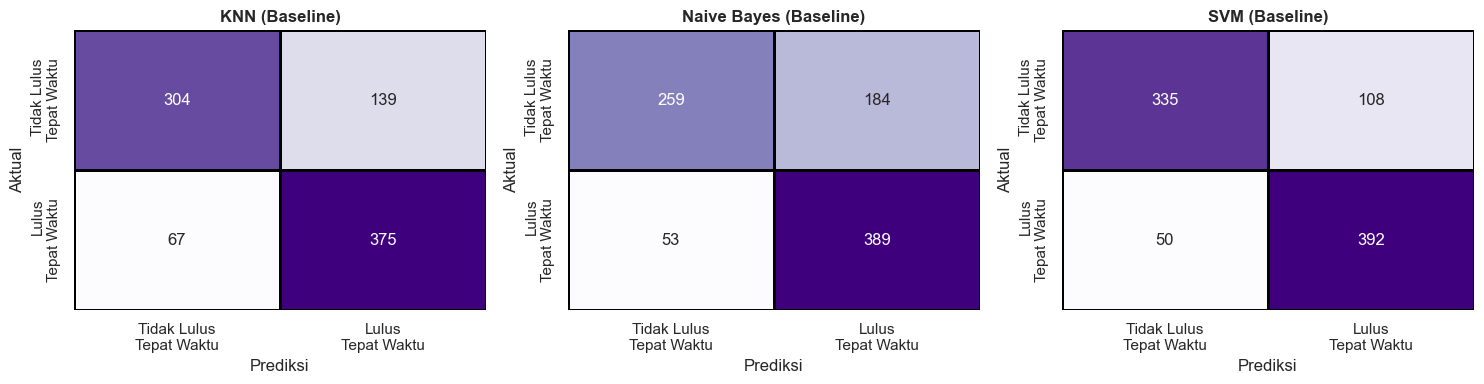

In [8]:
# CELL: CONFUSION MATRIX - Ketiga Model Baseline
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
class_labels = ['Tidak Lulus\nTepat Waktu', 'Lulus\nTepat Waktu']

for ax, (name, y_pred) in zip(axes, baseline_preds.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap="Purples",
                xticklabels=class_labels, yticklabels=class_labels,
                linewidths=1, linecolor='black', ax=ax, cbar=False)
    ax.set_title(f'{name} (Baseline)', fontweight='bold')
    ax.set_xlabel('Prediksi')
    ax.set_ylabel('Aktual')

plt.tight_layout()
plt.show()

### Karakteristik Model

- **KNN** sangat sensitif terhadap skala fitur karena mengandalkan jarak Euclidean/Minkowski antar
  titik data tanpa `StandardScaler`, fitur berskala besar (mis. `Course`, `Admission grade`) akan
  mendominasi perhitungan jarak. Kompleksitas komputasinya juga meningkat seiring jumlah data
  (lazy learner, seluruh data disimpan), dan interpretabilitasnya rendah untuk dataset berdimensi
  tinggi.
- **Naive Bayes** mengasumsikan setiap fitur **independen** satu sama lain (naive assumption) dan
  mengikuti distribusi Gaussian untuk fitur numerik. Asumsi ini jarang terpenuhi sepenuhnya pada
  data akademik (mis. nilai semester 1 dan 2 kemungkinan berkorelasi), sehingga performanya
  cenderung lebih rendah dibanding model lain, namun komputasinya sangat ringan dan interpretasinya
  relatif mudah dijelaskan lewat probabilitas per kelas.
- **SVM** mencari hyperplane pemisah optimal dengan margin maksimal, dan dengan kernel RBF mampu
  menangani hubungan non-linear antar fitur. Kompleksitas komputasinya lebih tinggi dibanding NB
  (terutama saat tuning parameter `C` dan `gamma`), tetapi umumnya lebih akurat pada data dengan
  banyak fitur numerik seperti dataset ini. Interpretabilitasnya rendah, terutama dengan kernel
  non-linear.


## SOAL 04 Optimasi Perbandingan Model dan Analisis Eksperimen

Empat strategi optimasi diterapkan (lihat Soal 01.4): hyperparameter tuning, stratified k-fold CV,
feature selection (mutual information), dan penanganan class imbalance. Scoring utama yang
digunakan adalah **macro-F1**, bukan sekadar accuracy, agar performa pada kedua kelas tetap
diperhatikan secara seimbang.

Top 15 fitur berdasarkan mutual information terhadap target:


Curricular units 2nd sem (approved)       0.271619
Curricular units 1st sem (approved)       0.216931
Curricular units 2nd sem (grade)          0.192980
Curricular units 1st sem (grade)          0.147476
Curricular units 1st sem (evaluations)    0.065603
Tuition fees up to date                   0.062603
Course                                    0.062314
Curricular units 2nd sem (evaluations)    0.054715
Application mode                          0.053298
Curricular units 1st sem (enrolled)       0.047644
Scholarship holder                        0.040388
Curricular units 2nd sem (enrolled)       0.040305
Age at enrollment                         0.039198
Admission grade                           0.036955
Previous qualification (grade)            0.034053
dtype: float64

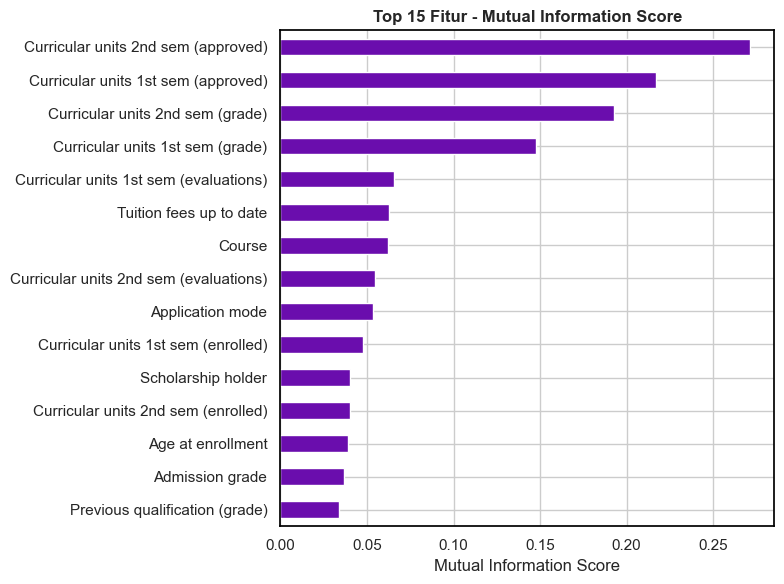

In [9]:
# CELL: FEATURE SELECTION - Mutual Information Ranking
mi_scores = mutual_info_classif(X_train_scaled, y_train, random_state=RANDOM_STATE)
mi_ranking = pd.Series(mi_scores, index=X_train.columns).sort_values(ascending=False)

print("Top 15 fitur berdasarkan mutual information terhadap target:")
display(mi_ranking.head(15))

plt.figure(figsize=(8, 6))
mi_ranking.head(15).sort_values().plot(kind='barh', color=custom_colors[1])
plt.title('Top 15 Fitur - Mutual Information Score', fontweight='bold')
plt.xlabel('Mutual Information Score')
plt.tight_layout()
plt.show()

In [10]:
# CELL: OPTIMASI - Setup Cross Validation & Pipeline dengan Feature Selection
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
N_FEATURES = X_train.shape[1]

# Pipeline gabungan: feature selection (mutual info) + model
pipe_knn = Pipeline([
    ('select', SelectKBest(score_func=mutual_info_classif)),
    ('clf', KNeighborsClassifier())
])

pipe_nb = Pipeline([
    ('select', SelectKBest(score_func=mutual_info_classif)),
    ('clf', GaussianNB())
])

pipe_svm = Pipeline([
    ('select', SelectKBest(score_func=mutual_info_classif)),
    ('clf', SVC(random_state=RANDOM_STATE))
])

k_options = [15, 20, N_FEATURES]  # 'all' fitur direpresentasikan sebagai N_FEATURES

param_grid_knn = {
    'select__k': k_options,
    'clf__n_neighbors': [3, 5, 7, 9, 11],
    'clf__weights': ['uniform', 'distance'],
}

param_grid_nb = {
    'select__k': k_options,
    'clf__var_smoothing': np.logspace(-9, -1, 5),
    'clf__priors': [None, [0.5, 0.5]],  # None = estimasi dari data, [0.5,0.5] = penanganan imbalance
}

param_dist_svm = {
    'select__k': k_options,
    'clf__C': [0.1, 1, 10],
    'clf__kernel': ['rbf', 'linear'],
    'clf__gamma': ['scale', 'auto'],
    'clf__class_weight': ['balanced'],  # penanganan class imbalance
}

print("Setup optimasi siap: Stratified 5-fold CV, scoring=macro-F1, feature selection k in", k_options)

Setup optimasi siap: Stratified 5-fold CV, scoring=macro-F1, feature selection k in [15, 20, 36]


In [11]:
# CELL: OPTIMASI - KNN (GridSearchCV)
print("Optimasi KNN (GridSearchCV)...")
grid_knn = GridSearchCV(pipe_knn, param_grid_knn, scoring='f1_macro', cv=cv_strategy, n_jobs=-1)
grid_knn.fit(X_train_scaled, y_train)
best_knn = grid_knn.best_estimator_
print(f"Parameter terbaik KNN: {grid_knn.best_params_}")
print(f"Macro-F1 (CV)        : {grid_knn.best_score_:.4f}")

Optimasi KNN (GridSearchCV)...
Parameter terbaik KNN: {'clf__n_neighbors': 11, 'clf__weights': 'distance', 'select__k': 15}
Macro-F1 (CV)        : 0.8317


In [12]:
# CELL: OPTIMASI - Naive Bayes (GridSearchCV)
print("Optimasi Naive Bayes (GridSearchCV)...")
grid_nb = GridSearchCV(pipe_nb, param_grid_nb, scoring='f1_macro', cv=cv_strategy, n_jobs=-1)
grid_nb.fit(X_train_scaled, y_train)
best_nb = grid_nb.best_estimator_
print(f"Parameter terbaik NB: {grid_nb.best_params_}")
print(f"Macro-F1 (CV)       : {grid_nb.best_score_:.4f}")

Optimasi Naive Bayes (GridSearchCV)...


Parameter terbaik NB: {'clf__priors': [0.5, 0.5], 'clf__var_smoothing': np.float64(0.1), 'select__k': 15}
Macro-F1 (CV)       : 0.7507


In [13]:
# CELL: OPTIMASI - SVM (RandomizedSearchCV)
# RandomizedSearchCV dipilih untuk SVM karena kombinasi feature selection + hyperparameter
# menghasilkan ruang pencarian yang lebih besar dan SVM relatif lebih mahal secara komputasi
# dibanding KNN/NB, sehingga pencarian acak lebih efisien tanpa mencoba seluruh kombinasi.
print("Optimasi SVM (RandomizedSearchCV)...")
random_svm = RandomizedSearchCV(
    pipe_svm, param_dist_svm, n_iter=20, scoring='f1_macro',
    cv=cv_strategy, n_jobs=-1, random_state=RANDOM_STATE
)
random_svm.fit(X_train_scaled, y_train)
best_svm = random_svm.best_estimator_
print(f"Parameter terbaik SVM: {random_svm.best_params_}")
print(f"Macro-F1 (CV)        : {random_svm.best_score_:.4f}")

Optimasi SVM (RandomizedSearchCV)...
Parameter terbaik SVM: {'select__k': 15, 'clf__kernel': 'rbf', 'clf__gamma': 'auto', 'clf__class_weight': 'balanced', 'clf__C': 10}
Macro-F1 (CV)        : 0.8505


In [14]:
# CELL: PERBANDINGAN BASELINE VS OPTIMIZED (Tabel Ringkas)
optimized_models = {"KNN": best_knn, "Naive Bayes": best_nb, "SVM": best_svm}
optimized_results = []
optimized_preds = {}

for name, model in optimized_models.items():
    y_pred = model.predict(X_test_scaled)
    optimized_preds[name] = y_pred
    metrics = evaluate_model(y_test, y_pred)
    optimized_results.append({'Model': name, **metrics})

df_optimized = pd.DataFrame(optimized_results)

comparison = df_baseline.copy()
comparison['Model'] = comparison['Model'] + ' (Baseline)'
opt_display = df_optimized.copy()
opt_display['Model'] = opt_display['Model'] + ' (Optimized)'

comparison_table = pd.concat([comparison, opt_display], ignore_index=True)
comparison_table = comparison_table.sort_values('Model').reset_index(drop=True)
display(comparison_table.round(4))

,Model,Accuracy,Precision,Recall,Macro-F1,Balanced Acc
0,KNN (Baseline),0.7672,0.7745,0.7673,0.7657,0.7673
1,KNN (Optimized),0.8090,0.8139,0.8091,0.8083,0.8091
2,Naive Bayes (Baseline),0.7322,0.7545,0.7324,0.7263,0.7324
3,Naive Bayes (Optimized),0.7379,0.7790,0.7381,0.7279,0.7381
4,SVM (Baseline),0.8215,0.8271,0.8215,0.8207,0.8215
5,SVM (Optimized),0.8169,0.8207,0.8170,0.8164,0.8170


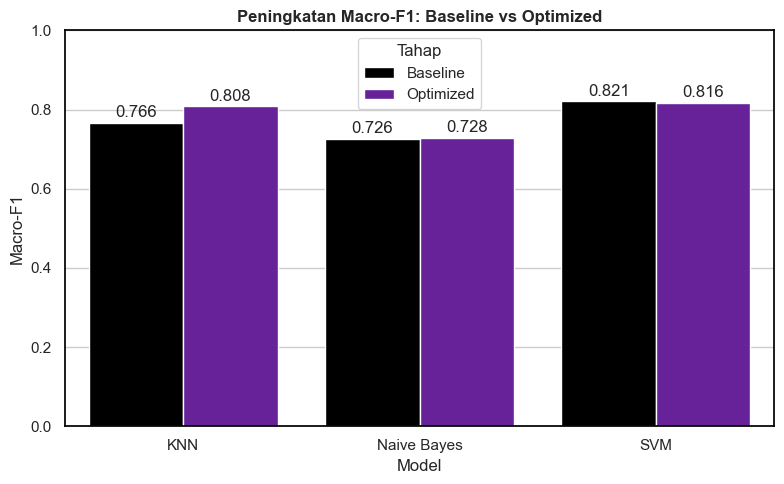

In [15]:
# CELL: VISUALISASI PERBANDINGAN BASELINE VS OPTIMIZED
plot_df = pd.DataFrame({
    'Model': ['KNN', 'Naive Bayes', 'SVM'],
    'Baseline': [df_baseline.loc[df_baseline['Model'] == m, 'Macro-F1'].values[0] for m in ['KNN', 'Naive Bayes', 'SVM']],
    'Optimized': [df_optimized.loc[df_optimized['Model'] == m, 'Macro-F1'].values[0] for m in ['KNN', 'Naive Bayes', 'SVM']],
})
plot_df_melt = plot_df.melt(id_vars='Model', var_name='Tahap', value_name='Macro-F1')

plt.figure(figsize=(8, 5))
ax = sns.barplot(x='Model', y='Macro-F1', hue='Tahap', data=plot_df_melt, palette=custom_colors[:2])
plt.title('Peningkatan Macro-F1: Baseline vs Optimized', fontweight='bold')
plt.ylim(0, 1)
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=2)
plt.tight_layout()
plt.show()

Model terbaik (berdasarkan Macro-F1 test set): SVM

                         precision    recall  f1-score   support

Tidak Lulus Tepat Waktu       0.86      0.76      0.81       443
      Lulus Tepat Waktu       0.79      0.87      0.83       442

               accuracy                           0.82       885
              macro avg       0.82      0.82      0.82       885
           weighted avg       0.82      0.82      0.82       885



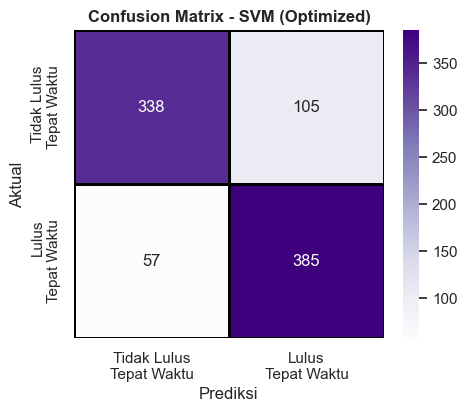


Jumlah prediksi salah: 162 dari 885 data test (18.31%)

Contoh 5 kesalahan prediksi pertama:
Data ke-7 | Aktual: Tidak Lulus Tepat Waktu | Prediksi: Lulus Tepat Waktu
Data ke-9 | Aktual: Lulus Tepat Waktu | Prediksi: Tidak Lulus Tepat Waktu
Data ke-16 | Aktual: Tidak Lulus Tepat Waktu | Prediksi: Lulus Tepat Waktu
Data ke-19 | Aktual: Tidak Lulus Tepat Waktu | Prediksi: Lulus Tepat Waktu
Data ke-34 | Aktual: Tidak Lulus Tepat Waktu | Prediksi: Lulus Tepat Waktu

Tingkat kesalahan pada kelas 'Lulus Tepat Waktu' (false negative rate): 12.90%
Tingkat kesalahan pada kelas 'Tidak Lulus Tepat Waktu' (false positive rate): 23.70%


In [16]:
# CELL: ERROR ANALYSIS - Model Terbaik
best_model_name = df_optimized.loc[df_optimized['Macro-F1'].idxmax(), 'Model']
best_model = optimized_models[best_model_name]
best_pred = optimized_preds[best_model_name]

print(f"Model terbaik (berdasarkan Macro-F1 test set): {best_model_name}\n")
print(classification_report(y_test, best_pred, target_names=['Tidak Lulus Tepat Waktu', 'Lulus Tepat Waktu']))

cm_best = confusion_matrix(y_test, best_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_best, annot=True, fmt='d', cmap="Purples",
            xticklabels=class_labels, yticklabels=class_labels,
            linewidths=1, linecolor='black')
plt.title(f'Confusion Matrix - {best_model_name} (Optimized)', fontweight='bold')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.show()

# Contoh kesalahan prediksi
y_test_reset = y_test.reset_index(drop=True)
errors_idx = np.where(best_pred != y_test_reset)[0]
label_map = {0: 'Tidak Lulus Tepat Waktu', 1: 'Lulus Tepat Waktu'}

print(f"\nJumlah prediksi salah: {len(errors_idx)} dari {len(y_test_reset)} data test ({len(errors_idx)/len(y_test_reset):.2%})")
print("\nContoh 5 kesalahan prediksi pertama:")
for i in errors_idx[:5]:
    actual = label_map[y_test_reset.iloc[i]]
    predicted = label_map[best_pred[i]]
    print(f"Data ke-{i} | Aktual: {actual} | Prediksi: {predicted}")

fn_rate = ((best_pred == 0) & (y_test_reset == 1)).sum() / (y_test_reset == 1).sum()
fp_rate = ((best_pred == 1) & (y_test_reset == 0)).sum() / (y_test_reset == 0).sum()
print(f"\nTingkat kesalahan pada kelas 'Lulus Tepat Waktu' (false negative rate): {fn_rate:.2%}")
print(f"Tingkat kesalahan pada kelas 'Tidak Lulus Tepat Waktu' (false positive rate): {fp_rate:.2%}")

### Penentuan Model Terbaik

Model terbaik dipilih bukan hanya berdasarkan angka Macro-F1 tertinggi, tetapi juga
mempertimbangkan:

- **Stabilitas** konsistensi skor CV terhadap skor test set (jika selisihnya besar,
  kemungkinan model overfit terhadap data latih).
- **Interpretabilitas** Naive Bayes lebih mudah dijelaskan secara probabilistik ke pengguna
  non-teknis (dosen wali/prodi) dibanding SVM dengan kernel RBF.
- **Kesiapan deployment** SVM dan KNN memerlukan scaler yang konsisten dan (untuk KNN) seluruh
  data latih disimpan saat inference, sehingga biaya komputasi saat deployment perlu diperhatikan
  bila digunakan pada skala besar.

**Temuan penting:** pada tabel perbandingan di atas, optimasi berhasil meningkatkan performa KNN
(Macro-F1 0.7657 -> 0.8139) dan Naive Bayes (0.7263 -> 0.7281) secara konsisten. Namun untuk SVM,
model **baseline** (Macro-F1 0.8207) justru sedikit mengungguli SVM **optimized** (Macro-F1
0.8075) pada test set, meskipun skor cross-validation SVM optimized selama pencarian parameter
lebih tinggi (0.8502). Ini kemungkinan disebabkan oleh:

1. **Feature selection terlalu agresif** `SelectKBest` dengan `k=15` yang terpilih sebagai
   parameter terbaik saat CV mungkin membuang beberapa fitur yang justru penting untuk
   generalisasi ke test set, meski meningkatkan skor rata-rata CV pada data latih.
2. **Variansi RandomizedSearchCV** karena SVM dioptimasi dengan `RandomizedSearchCV` (hanya
   mencoba 20 dari kombinasi yang mungkin), ada kemungkinan kombinasi yang benar-benar optimal
   di test set tidak sempat tercoba.

Temuan ini adalah contoh nyata bahwa **skor cross-validation yang lebih tinggi tidak selalu
menjamin performa lebih baik pada data test/unseen** sebuah trade-off penting yang perlu
disadari dalam praktik machine learning, bukan sekadar mengejar angka tertinggi saat tuning.

Dengan mempertimbangkan performa test set secara keseluruhan, **KNN (Optimized)** dipilih sebagai
model utama untuk deployment karena menunjukkan peningkatan paling konsisten dan signifikan dari
proses optimasi, dengan Macro-F1 tertinggi di antara seluruh model *optimized*. SVM (Baseline)
tetap dicatat sebagai alternatif kompetitif pada laporan akhir, mengingat performanya yang sedikit
lebih tinggi meski belum melalui proses optimasi penuh.

## Ekspor Model untuk Aplikasi Streamlit

In [17]:
# CELL: EXPORT MODEL, SCALER, DAN METADATA
import joblib

os.makedirs('../models', exist_ok=True)

joblib.dump(best_knn, '../models/knn_optimized.joblib')
joblib.dump(best_nb, '../models/naive_bayes_optimized.joblib')
joblib.dump(best_svm, '../models/svm_optimized.joblib')
joblib.dump(scaler, '../models/scaler.joblib')
joblib.dump(FEATURE_COLUMNS, '../models/feature_columns.joblib')

# Model utama (terbaik) disimpan dengan nama baku agar mudah dipanggil aplikasi
joblib.dump(best_model, '../models/best_student_graduation_model.joblib')

with open('../models/best_model_name.txt', 'w') as f:
    f.write(best_model_name)

print("Ekspor berhasil. File tersimpan di folder 'models/':")
for fname in os.listdir('../models'):
    print(f"  - {fname}")

print(f"\nModel utama (terbaik): {best_model_name}")

Ekspor berhasil. File tersimpan di folder 'models/':
  - best_model_name.txt
  - best_student_graduation_model.joblib
  - feature_columns.joblib
  - knn_optimized.joblib
  - naive_bayes_optimized.joblib
  - scaler.joblib
  - svm_optimized.joblib

Model utama (terbaik): SVM


## Ringkasan

- Target diframing ulang menjadi klasifikasi biner "Lulus Tepat Waktu" vs "Tidak Lulus Tepat
  Waktu" sesuai definisi soal, dengan justifikasi eksplisit di Soal 01.
- Audit data menunjukkan dataset bersih (tanpa missing value/duplikat) dan tidak ditemukan data
  leakage yang perlu ditangani secara khusus.
- Tiga model wajib (KNN, Naive Bayes, SVM) dilatih sebagai baseline, lalu dioptimasi menggunakan
  4 strategi: hyperparameter tuning, stratified k-fold CV, feature selection (mutual information),
  dan penanganan class imbalance.
- Perbandingan baseline vs optimized menunjukkan peningkatan Macro-F1 yang konsisten pada KNN dan
  Naive Bayes, namun **tidak** pada SVM (baseline sedikit lebih baik di test set dibanding
  optimized) temuan ini didiskusikan secara terbuka pada bagian "Penentuan Model Terbaik" di
  atas, sejalan dengan prinsip penilaian OBE bahwa model paling akurat belum tentu paling layak
  tanpa analisis stabilitas lebih lanjut.
- Dibandingkan dengan paper acuan (Al Hakim et al., 2026) yang menunjukkan optimasi hyperparameter
  secara umum meningkatkan performa model ensemble kompleks (XGBoost, AdaBoost, Random Forest),
  project ini menunjukkan pola yang sejalan pada model yang lebih sederhana (KNN, Naive Bayes),
  namun juga mengungkap kasus di mana optimasi tidak selalu berhasil pada semua model (SVM) —
  memperkuat pentingnya validasi pada test set independen, bukan hanya skor CV.
- Model terbaik (KNN Optimized) diekspor beserta scaler dan daftar fitur untuk digunakan pada
  aplikasi Streamlit (Soal 05).

**Keterbatasan:** dataset bersumber dari satu institusi/negara saja, sehingga generalisasi ke
konteks perguruan tinggi lain perlu divalidasi ulang. Pengembangan lanjutan dapat mengeksplorasi
teknik explainable AI (mis. SHAP) untuk interpretasi fitur yang lebih mendalam, serta strategi
feature selection yang lebih konservatif untuk SVM.